# Importing libraries

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor




In [2]:
#!pip install xgboost

In [3]:
#Versions of the libraries
print("numpy:",np.__version__)
print("Pandas:",pd.__version__)
print("SKlearn:",sklearn.__version__)

numpy: 2.4.3
Pandas: 3.0.2
SKlearn: 1.8.0


# Loading dataset

In [4]:
df=pd.read_csv('Premiumdata.csv')
print("Data loaded successfully:")
print("\nShape of the dataset is :",df.shape)
print("\nThe size of the dataset is :",df.size)

df.head()


Data loaded successfully:

Shape of the dataset is : (100000, 22)

The size of the dataset is : 2200000


,person_id,age,sex,dependents,bmi,smoker,alcohol_freq,hospitalizations_last_3yrs,annual_medical_cost,annual_premium,...,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure
0,75722,52,Female,1,27.4,Never,NaN,0,6938.06,876.05,...,0,0,0,0,0,0,0,1,0,0
1,80185,79,Female,1,26.6,Never,Weekly,0,1632.61,445.10,...,0,0,0,0,0,0,0,1,1,0
2,19865,68,Male,3,31.5,Never,NaN,0,7661.01,1538.02,...,0,0,0,0,1,0,0,0,1,0
3,76700,15,Male,3,31.6,Never,NaN,0,5130.27,820.63,...,1,0,0,0,0,0,0,0,0,0
4,92992,53,Male,0,30.5,Never,Daily,0,1700.73,500.93,...,0,0,0,0,0,0,0,1,0,0


In [5]:
df.describe()

,person_id,age,dependents,bmi,hospitalizations_last_3yrs,annual_medical_cost,annual_premium,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,0.898380,26.990512,0.093640,3009.451907,582.320040,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.169700
std,28867.657797,15.988752,0.950654,4.994883,0.304848,3127.462822,399.583722,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.375371
min,1.000000,0.000000,0.000000,12.000000,0.000000,55.550000,211.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,0.000000,23.600000,0.000000,1175.117500,352.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,1.000000,27.000000,0.000000,2082.575000,463.585000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,1.000000,30.400000,0.000000,3707.957500,666.697500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,100000.000000,100.000000,7.000000,50.400000,3.000000,65724.900000,10962.550000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   person_id                   100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   sex                         100000 non-null  str    
 3   dependents                  100000 non-null  int64  
 4   bmi                         100000 non-null  float64
 5   smoker                      100000 non-null  str    
 6   alcohol_freq                69917 non-null   str    
 7   hospitalizations_last_3yrs  100000 non-null  int64  
 8   annual_medical_cost         100000 non-null  float64
 9   annual_premium              100000 non-null  float64
 10  chronic_count               100000 non-null  int64  
 11  hypertension                100000 non-null  int64  
 12  diabetes                    100000 non-null  int64  
 13  asthma                    

In [7]:
#Percentage of missing values in each column
(df.isnull().sum() / len(df)) * 100

person_id                      0.000
age                            0.000
sex                            0.000
dependents                     0.000
bmi                            0.000
smoker                         0.000
alcohol_freq                  30.083
hospitalizations_last_3yrs     0.000
annual_medical_cost            0.000
annual_premium                 0.000
chronic_count                  0.000
hypertension                   0.000
diabetes                       0.000
asthma                         0.000
copd                           0.000
cardiovascular_disease         0.000
cancer_history                 0.000
kidney_disease                 0.000
liver_disease                  0.000
arthritis                      0.000
mental_health                  0.000
had_major_procedure            0.000
dtype: float64

In [8]:
#handling missing values
df['alcohol_freq'].fillna('Never',inplace=True)

C:\Users\Shivraj\AppData\Local\Temp\ipykernel_12008\2540496839.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['alcohol_freq'].fillna('Never',inplace=True)


0             Never
1            Weekly
2             Never
3             Never
4             Daily
            ...    
99995    Occasional
99996    Occasional
99997        Weekly
99998    Occasional
99999         Never
Name: alcohol_freq, Length: 100000, dtype: str

In [9]:
df.columns
df.drop(columns=['person_id'],inplace=True)

In [10]:
#handling categorical input features
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Weekly        19833
Daily          5006
Name: count, dtype: int64

# Exploratory Data analysis

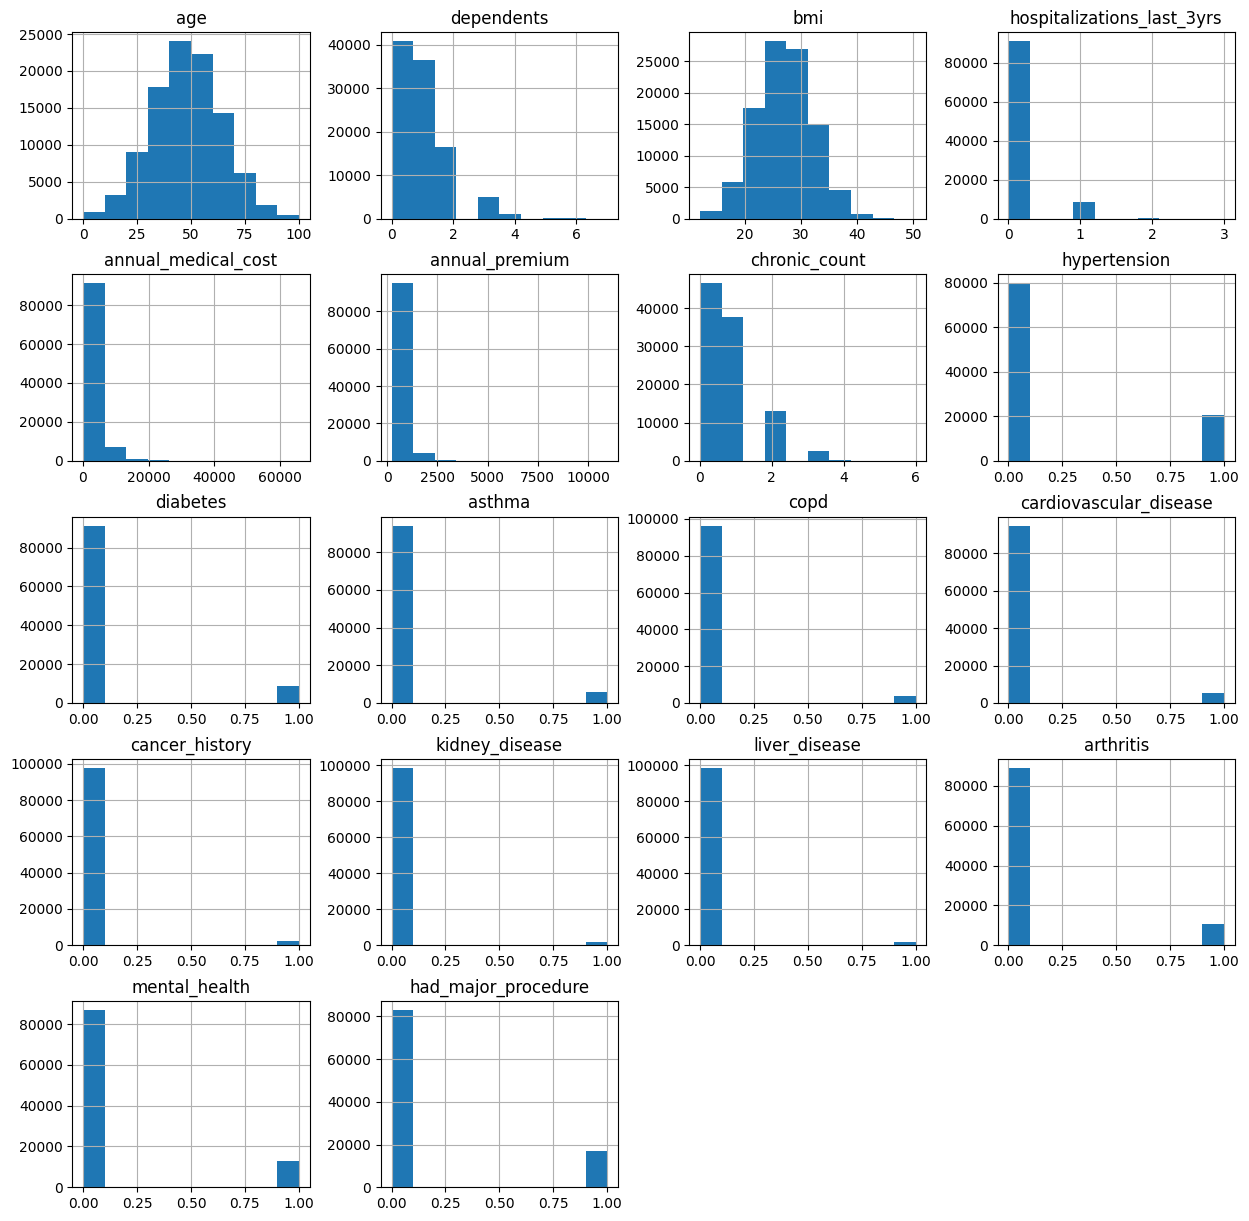

In [11]:
#Input numerical  feature distn
import matplotlib.pyplot as plt

df.hist(figsize=(15,15))
plt.show()

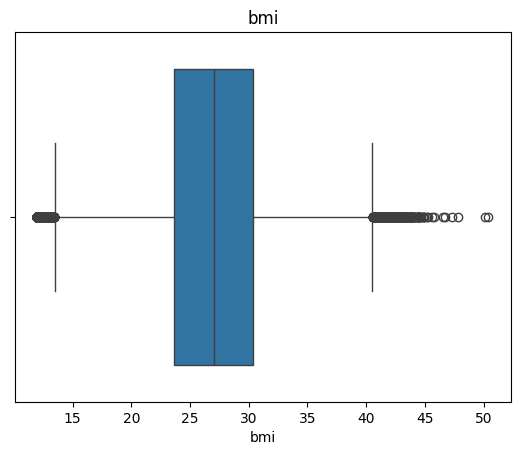

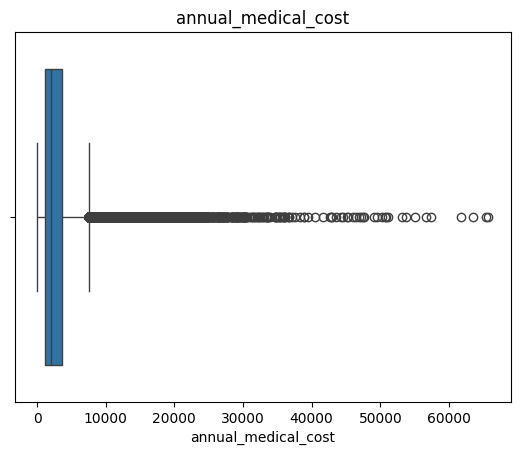

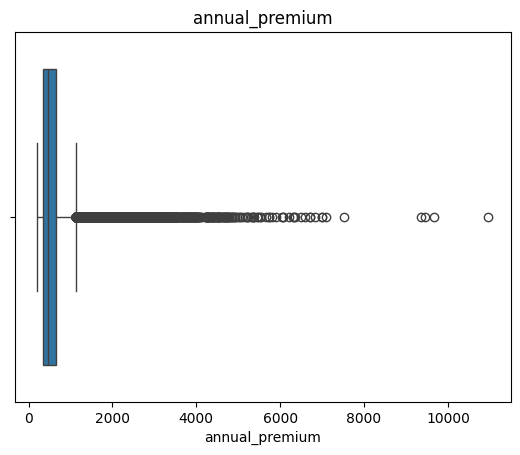

In [12]:
# boxplot for outlier detection
import seaborn as sns

for col in df.select_dtypes(include=['float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [13]:
# Value count of categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f'\n{df[col].value_counts()}')



sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

smoker
Never      69709
Former     18163
Current    12128
Name: count, dtype: int64

alcohol_freq
Occasional    45078
Weekly        19833
Daily          5006
Name: count, dtype: int64


C:\Users\Shivraj\AppData\Local\Temp\ipykernel_12008\1949933492.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


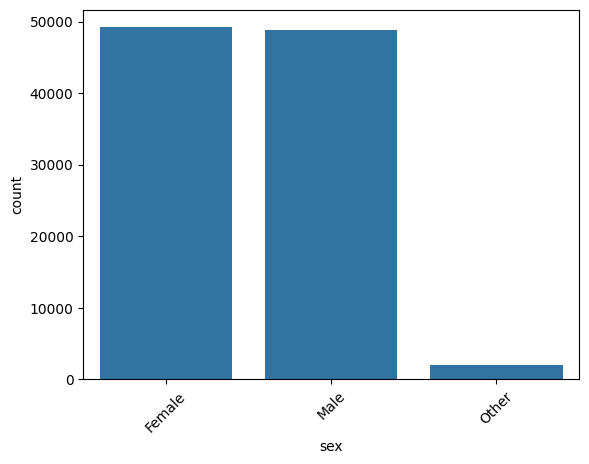

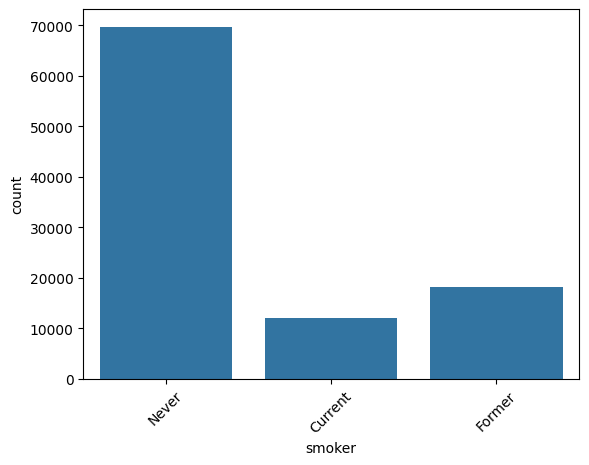

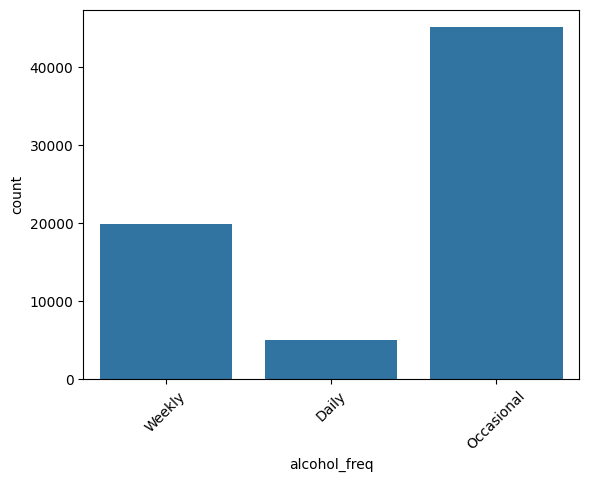

In [14]:
#EDA for categorical columns
for col in ['sex','smoker','alcohol_freq']:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

<Axes: >

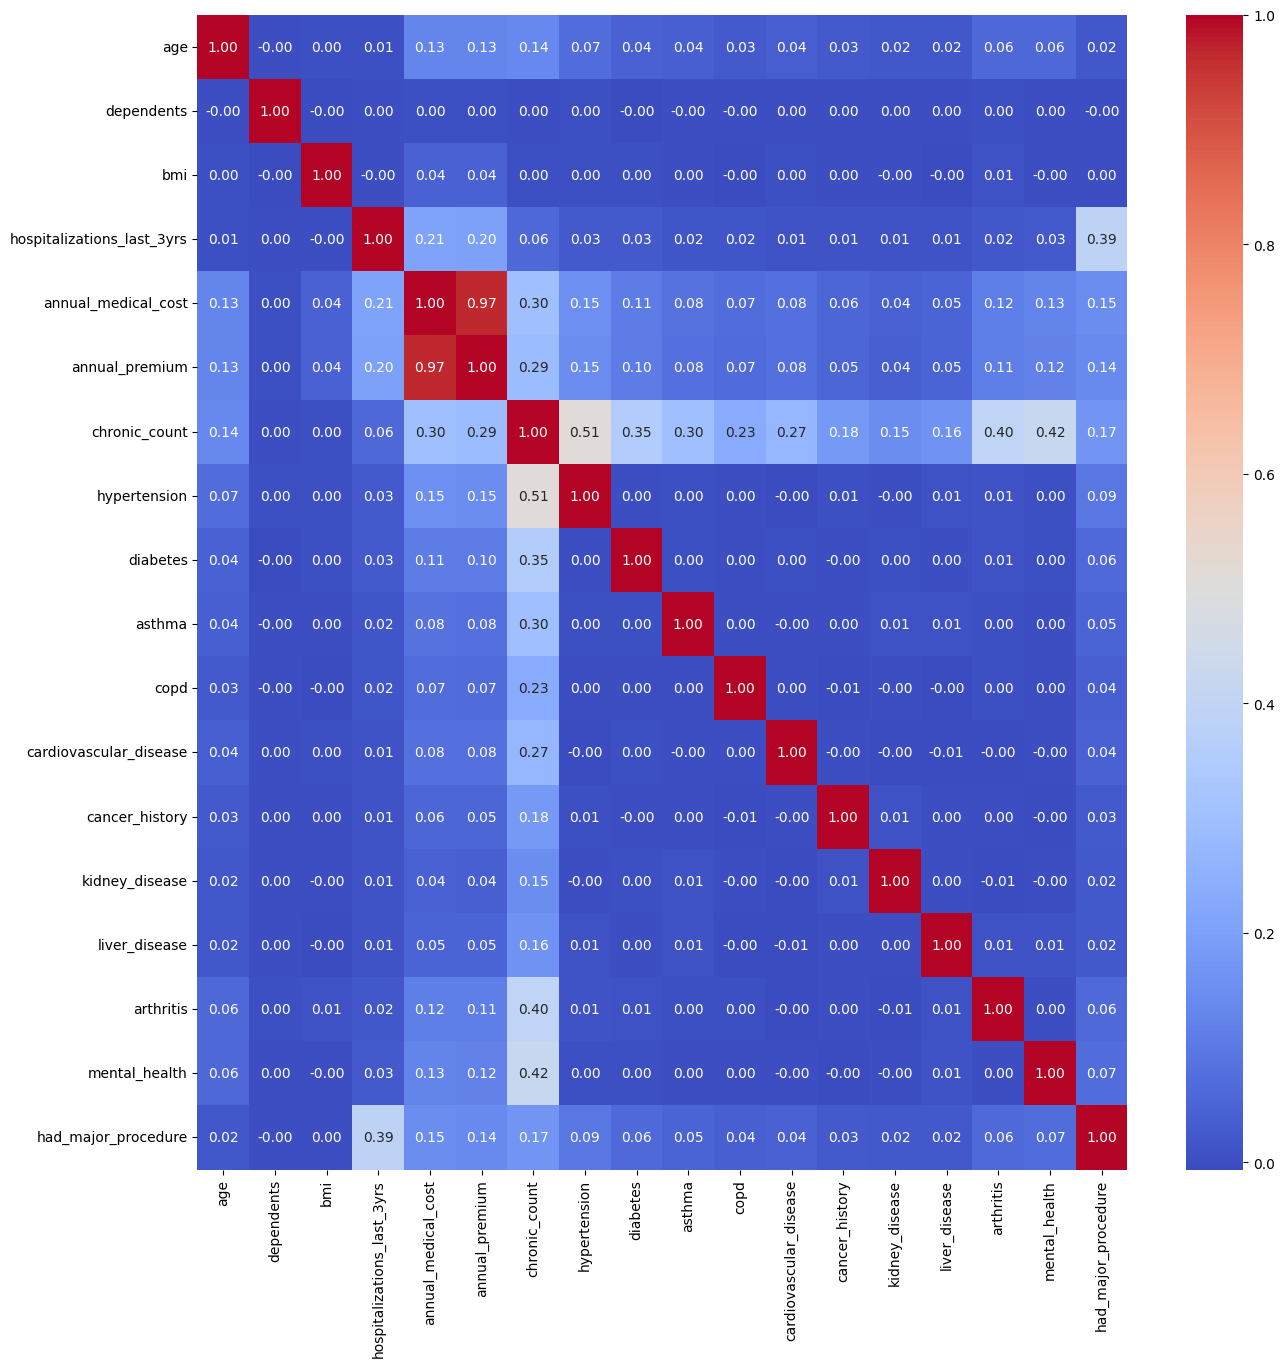

In [15]:
#One hot encoding for categorical columns
#df_encoded = pd.get_dummies(df, columns=['sex','smoker','alcohol_freq'], drop_first=True)

corr =df.corr(numeric_only=True)
#corr['annual_premium'].sort_values(ascending=False)
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')



<Axes: xlabel='annual_premium', ylabel='Count'>

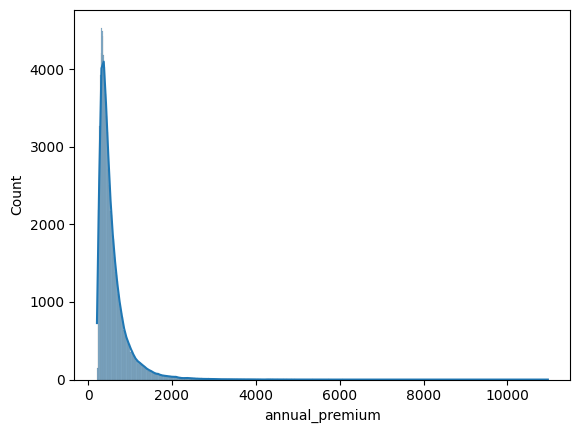

In [16]:
import seaborn as sns
sns.histplot(df['annual_premium'], kde=True)

In [17]:
#To check the relation between disease and annual average premium
disease_cols = [
    'hypertension','diabetes','asthma','copd',
    'cardiovascular_disease','cancer_history',
    'kidney_disease','liver_disease','arthritis','mental_health'
]

for col in disease_cols:
    print(df.groupby(col)['annual_premium'].mean())
df.head()

hypertension
0    552.568081
1    698.805282
Name: annual_premium, dtype: float64
diabetes
0    569.530649
1    718.365635
Name: annual_premium, dtype: float64
asthma
0    574.401895
1    708.904102
Name: annual_premium, dtype: float64
copd
0    577.154106
1    720.851844
Name: annual_premium, dtype: float64
cardiovascular_disease
0    575.229202
1    713.803322
Name: annual_premium, dtype: float64
cancer_history
0    579.144938
1    726.755444
Name: annual_premium, dtype: float64
kidney_disease
0    580.332399
1    716.285964
Name: annual_premium, dtype: float64
liver_disease
0    579.833482
1    748.185369
Name: annual_premium, dtype: float64
arthritis
0    566.747681
1    710.523500
Name: annual_premium, dtype: float64
mental_health
0    563.547676
1    707.795131
Name: annual_premium, dtype: float64


,age,sex,dependents,bmi,smoker,alcohol_freq,hospitalizations_last_3yrs,annual_medical_cost,annual_premium,chronic_count,...,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure
0,52,Female,1,27.4,Never,NaN,0,6938.06,876.05,1,...,0,0,0,0,0,0,0,1,0,0
1,79,Female,1,26.6,Never,Weekly,0,1632.61,445.10,2,...,0,0,0,0,0,0,0,1,1,0
2,68,Male,3,31.5,Never,NaN,0,7661.01,1538.02,3,...,0,0,0,0,1,0,0,0,1,0
3,15,Male,3,31.6,Never,NaN,0,5130.27,820.63,1,...,1,0,0,0,0,0,0,0,0,0
4,53,Male,0,30.5,Never,Daily,0,1700.73,500.93,2,...,0,0,0,0,0,0,0,1,0,0


# Encoding Part 

In [18]:
X=df.drop(columns=['dependents','chronic_count','asthma','copd','cardiovascular_disease','cancer_history','kidney_disease','liver_disease','annual_premium'])
y=df['annual_premium']
num_features = X.select_dtypes(exclude="object").columns
onehot_columns = ['smoker','sex','alcohol_freq']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, onehot_columns),
        
        
    ],remainder='passthrough'
    
)

# Train test Split

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

# model building

In [20]:
#Random forest algorithm 
rf=RandomForestRegressor(n_jobs=-1)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
#Gradient Boosting Algorithm
Gboost=GradientBoostingRegressor()
Gboost.fit(X_train,y_train)
y_pred_gboost=Gboost.predict(X_test)

In [22]:
#XG boost algorithm
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [23]:
y_pred_xgb=xgb.predict(X_test)

# Model Evaluation

In [24]:
y_pred_rf=rf.predict(X_test)
from sklearn.metrics import r2_score,mean_squared_error
print("r2 score for rf is :",r2_score(y_test,y_pred_rf))
print("r2 score for GD is :",r2_score(y_test,y_pred_gboost))
print("r2 score for XGB is :",r2_score(y_test,y_pred_xgb))
print("mse score for rf is :",mean_squared_error(y_test,y_pred_rf))
print("mse score for GD is :",mean_squared_error(y_test,y_pred_gboost))
print("mse score for XGB is :",mean_squared_error(y_test,y_pred_xgb))


r2 score for rf is : 0.9248022876574138
r2 score for GD is : 0.9300768080477999
r2 score for XGB is : 0.892246329344757
mse score for rf is : 11967.203012198022
mse score for GD is : 11127.799068416325
mse score for XGB is : 17148.26172059677


In [25]:
X_test.shape
X.head()

,age,sex,bmi,smoker,alcohol_freq,hospitalizations_last_3yrs,annual_medical_cost,hypertension,diabetes,arthritis,mental_health,had_major_procedure
0,52,Female,27.4,Never,NaN,0,6938.06,0,0,1,0,0
1,79,Female,26.6,Never,Weekly,0,1632.61,0,0,1,1,0
2,68,Male,31.5,Never,NaN,0,7661.01,1,0,0,1,0
3,15,Male,31.6,Never,NaN,0,5130.27,0,1,0,0,0
4,53,Male,30.5,Never,Daily,0,1700.73,1,0,1,0,0


# Testing on new data point

In [26]:
new_data = pd.DataFrame({
    'age': [50],
    'sex': ['Male'],
    'bmi': [30],
    'hospitalizations_last_3yrs': [2],
    'annual_medical_cost': [20000],
    'hypertension': [1],
    'diabetes': [0],
    'arthritis': [0],
    'mental_health': [1],
    'had_major_procedure': [0],
    'smoker': ['Never'],
    'alcohol_freq': ['Weekly']
})

In [27]:
new_data_transformed = preprocessor.transform(new_data)
print(new_data_transformed.shape)

(1, 16)


In [28]:
prediction = Gboost.predict(new_data_transformed)
print(prediction)

[2626.30408775]


# Pickle File Dump

In [29]:
'''import pickle

# save model
with open("gboost_model.pkl", "wb") as f:
    pickle.dump(Gboost, f)

# save preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)'''

'import pickle\n\n# save model\nwith open("gboost_model.pkl", "wb") as f:\n    pickle.dump(Gboost, f)\n\n# save preprocessor\nwith open("preprocessor.pkl", "wb") as f:\n    pickle.dump(preprocessor, f)'